In [7]:
import numpy as np

def rk45_step(f, t0, y0, h, A, c, b, b_):                       
    y0 = np.array(y0)
    d = len(y0)
    k = np.zeros((6, d))     
    t = t0
    y = y0

    for i in range(6):
        suma = np.zeros(d)   
        for j in range(i):
            suma += A[i][j] * k[j] 
        k[i] = f(t + c[i] * h, y + h * suma)

    y1  = y + h * np.dot(b, k)    
    y1_ = y + h * np.dot(b_, k)   
    return y1, y1_

def test(t, y):
    return y  

A = np.array([[0, 0, 0, 0, 0, 0],
    [1/4, 0, 0, 0, 0, 0],
    [3/32, 9/32, 0, 0, 0, 0],
    [1932/2197, -7200/2197, 7296/2197, 0, 0, 0],
    [439/216, -8, 3680/513, -845/4104, 0, 0],
    [-8/27, 2, -3544/2565, 1859/4104, -11/40, 0]])
c = np.array([0, 1/4, 3/8, 12/13, 1, 1/2])
b = np.array([25/216, 0, 1408/2565, 2197/4104, -1/5, 0])
b_ = np.array([16/135, 0, 6656/12825, 28561/56430, -9/50, 2/55])
h = 0.1
t0 = 0
y0 = np.array([1])

y1, y1_ = rk45_step(test, t0, y0, h, A, c, b, b_)
error = np.linalg.norm(y1_ - y1)
print(y1)
print(error)

[1.10517093]
1.2339743449274465e-08


In [11]:
import numpy as np

def integrar_adaptativo(f, t0, y0, t1, atol, rtol):
    t = t0
    y = np.array(y0, dtype=float)
    h = 0.01

    ts, ys, hs = [t], [y], [h]

    while t < t1:
        if t + h > t1: h = t1 - t

        y5, y4 = rk45_step(f, t, y, h, A, c, b, b_)

        err_abs = np.linalg.norm(y5 - y4)
        sc = atol + np.max([np.linalg.norm(y), np.linalg.norm(y5)]) * rtol
        err = err_abs / sc if sc > 0 else 1.0

        if (err <= 1.0) or (h < 1e-10):
            t += h
            y = y5
            ts.append(t)
            ys.append(y)
            hs.append(h)
            if err == 0: h *= 2.0
            else: h = h * (1.0 / err) ** 0.2
        else: 
            h = h * (1.0 / err) ** 0.2
        
        h = np.clip(h, 1e-10, 0.5)

    return np.array(ts), np.array(ys), np.array(hs)

def kepler_ode(t, state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    return np.array([vx, vy, -x / r**3, -y / r**3])


# Condiciones iniciales (Órbita muy elíptica)
# x=1, y=0, vx=0, vy=0.5
y0 = [1.0, 0.0, 0.0, 0.5]
t0 = 0.0
t1 = 15.0
atol1 = 1e-12
rtol2 = 1e-12
tolerancia = 1e-6


# Resolver
t_hist, y_hist, h_hist = integrar_adaptativo(kepler_ode, t0, y0, t1, atol1, rtol2)

print(f"Simulación terminada con {len(t_hist)} pasos.")

Simulación terminada con 3183 pasos.


ValueError: x and y must have same first dimension, but have shapes (3182,) and (3183,)

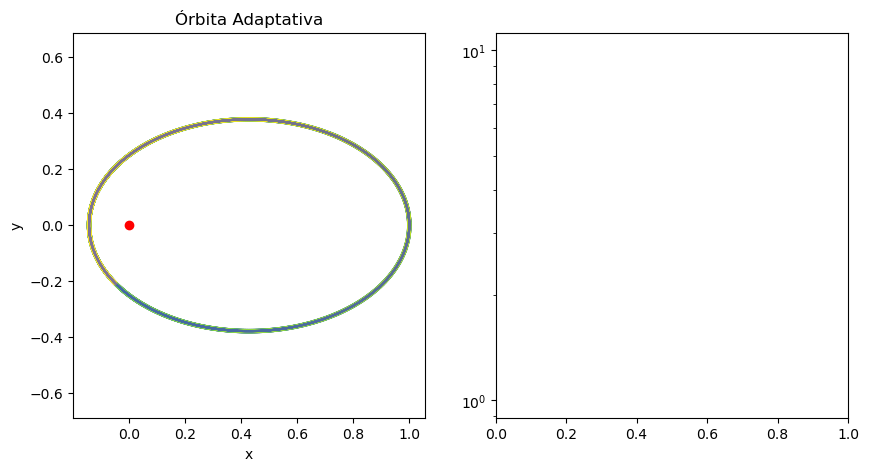

In [10]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))

# Gráfico 1: Trayectoria
plt.subplot(1, 2, 1)
plt.plot(y_hist[:, 0], y_hist[:, 1], 'b-', alpha=0.5)
plt.scatter(y_hist[:, 0], y_hist[:, 1], c=t_hist, s=5, cmap='viridis')
plt.plot(0, 0, 'ro', label='Sol')
plt.axis('equal')
plt.title("Órbita Adaptativa")
plt.xlabel("x")
plt.ylabel("y")

# Gráfico 2: Tamaño de paso vs Distancia
dist = np.sqrt(y_hist[:-1, 0]**2 + y_hist[:-1, 1]**2)
plt.subplot(1, 2, 2)
plt.semilogy(t_hist[:-1], h_hist, 'r.-', label="Paso h")
plt.title("Adaptatividad del Paso")
plt.xlabel("Tiempo")
plt.ylabel("Tamaño del paso (log)")
plt.grid(True)

plt.tight_layout()
plt.show()